### インポート

In [2]:
import preprocessing
from train import Trainer
import create_population
from feature_engeneering import PredictionFeatureCreator
from predict import predict
%load_ext autoreload

### 学習母集団の作成
期間を指定すると、学習母集団である(日付、horse_id、race_id)の組を作る

In [9]:
population = create_population.create(
    from_ = "2018-01-01",
    to_ = "2025-01-10"
)

In [10]:
population["race_id"].nunique()

22880

In [ ]:
results_preprocessed = preprocessing.process_results()

In [140]:
results_preprocessed.query("horse_id == 2020104640")

,race_id,horse_id,jockey_id,trainer_id,rank_furlongs,rank,wakuban,umaban,sex,age,weight,weight_diff,tansho_odds,popularity,impost,time,time_rank


In [23]:
horse_results_preprocessed = preprocessing.process_horse_results()

/home/mech-user/KEI.AI/v1_0_2/src/preprocessing.py:114: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_dir / "horse_results.csv", sep = "\t").query(


In [50]:
race_info_preprocesed = preprocessing.process_race_info()

In [49]:
hose_info_preprocessed = preprocessing.process_horse_info()

### 学習用csvファイルの作成

In [ ]:
import feature_engeneering
df  = feature_engeneering.FeatureCreater()
features = df.create_features()

100%|██████████| 5/5 [00:09<00:00,  1.96s/it]


In [ ]:
features[["race_id", "month"]]

,race_id,month
0,202209020111,3
1,202209020111,3
2,202209020111,3
3,202209020111,3
4,202209020111,3
...,...,...
313517,202308020604,10
313518,202308020604,10
313519,202308020604,10
313520,202308020604,10


In [ ]:
df.dist["relative_front"].value_counts(dropna=False)

relative_front
 0.000000    59959
-0.250000     9003
-0.258199     5096
-0.250000     4890
-0.002977     4578
             ...  
-1.806363        1
-0.257740        1
 0.774806        1
 0.637498        1
-0.433499        1
Name: count, Length: 45281, dtype: int64

In [ ]:
features[["horse_id", "relative_front"]]

,horse_id,relative_front
0,2019105318,1.874388
1,2019103826,-0.530800
2,2019105556,-0.530800
3,2019102632,1.874388
4,2019105277,-0.530800
...,...,...
236578,2021105984,-0.002817
236579,2021101637,-0.002817
236580,2021105490,-0.002817
236581,2021104223,-0.002817


### 学習

In [15]:
%reload_ext autoreload
from train import Trainer


In [3]:
%autoreload

In [16]:
# target_mod
trainer = Trainer(config_filepath="config_new.yaml")
evaluation_df = trainer.run(
    test_start_date="2024-01-01",
    valid_start_date="2023-01-01"
    )

[LightGBM] [Warning] Unknown parameter: lamda_l1
[LightGBM] [Warning] Unknown parameter: lamda_l2
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Unknown parameter: lamda_l1
[LightGBM] [Warning] Unknown parameter: lamda_l2
[LightGBM] [Info] Number of positive: 21967, number of negative: 215542
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.132376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54326
[LightGBM] [Info] Number of data points in the train set: 237509, number of used features: 151
[LightGBM] [Warning] Unknown parameter: lamda_l1
[LightGBM] [Warning] Unknown parameter: lamda_l2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.092489 -> initscore=-2.283614
[LightGBM] [Info] Start trainin

In [4]:
# target
trainer = Trainer(config_filepath="config_new.yaml")
evaluation_df = trainer.run(
    test_start_date="2024-01-01",
    valid_start_date="2023-01-01"
    )

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 21967, number of negative: 215542
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.143534 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54326
[LightGBM] [Info] Number of data points in the train set: 237509, number of used features: 151
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.092489 -> initscore=-2.283614
[LightGBM] [Info] Start training from score -2.283614
Training until validation scores don't improve for 20 rounds
[5]	valid_0's binary_logloss: 0.275577
[10]	valid_0's binary_logloss: 0.261848
[15]	valid_0's binary_logloss: 0.254002
[20]	valid_0's binary_logloss: 0.249302
[25]	valid_0's binary_logloss: 0.246399
[30]	valid_

a = 10
的中率 = 0.34236804564907275
回収率 = 0.8991440798858774

a = 11
的中率 = 0.34236804564907275
回収率 = 0.8991440798858774

a = 12
的中率 = 0.34759866856871136
回収率 = 0.9069424631478841

a = 13
的中率 = 0.3461721350451736
回収率 = 0.8986210175939134

a = 14
的中率 = 0.34950071326676174
回収率 = 0.8941036614360438

a = 12 が適切と判断

In [ ]:
len(df[df["expected_value"]>1.6])

84

普通の期待値でやると賭けれる馬の数が年間約3500レースに対して少なすぎるし、旨味も少ない

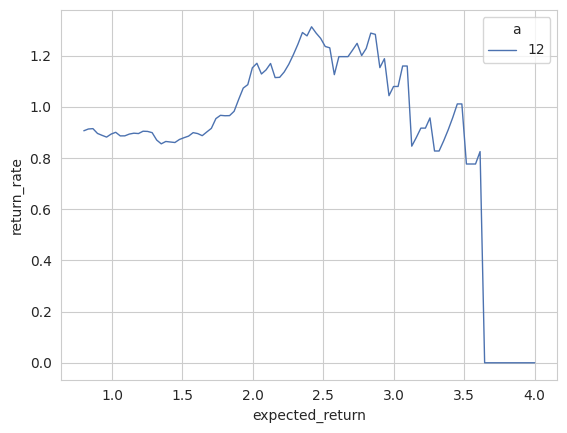

In [ ]:
# 閾値15
import improve_pred
df = improve_pred.plot()

In [9]:
# 閾値2.3のときの年間賭けれる回数、的中率
print(len(df[df["expected_value"]>2.3]))
print(df[df["expected_value"]>2.3]["target"].sum()/len(df[df["expected_value"]>2.3]))

89
0.2808988764044944


In [ ]:
# 閾値2.0のときの年間賭けれる回数、的中率
print(len(df[df["expected_value"]>2.0]))
print(df[df["expected_value"]>2.0]["target"].sum()/len(df[df["expected_value"]>2.0]))

177
0.3107344632768362


期待値約1.2かつ頭数も比較的多いので期待値の閾値は2.0を採用

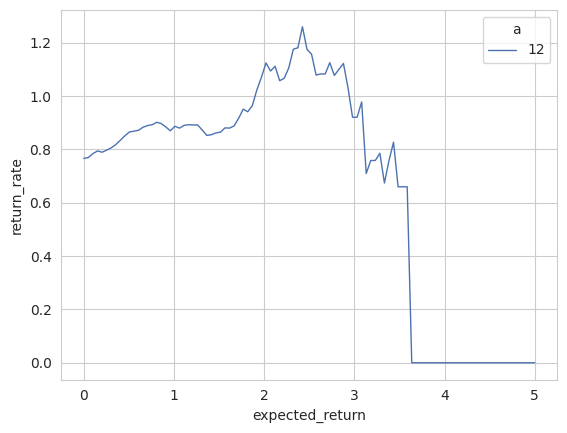

In [ ]:
# 閾値20
import improve_pred
df = improve_pred.plot()

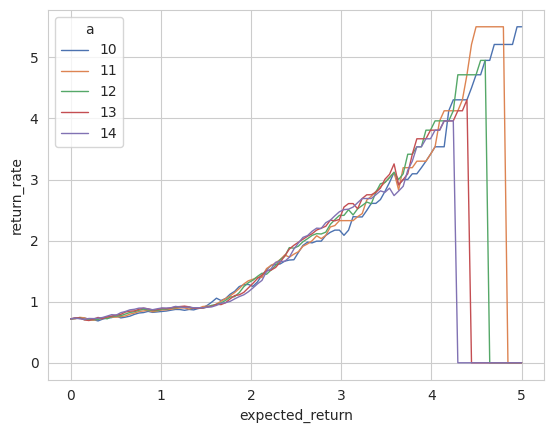

In [1]:
import improve_pred
improve_pred.plot()


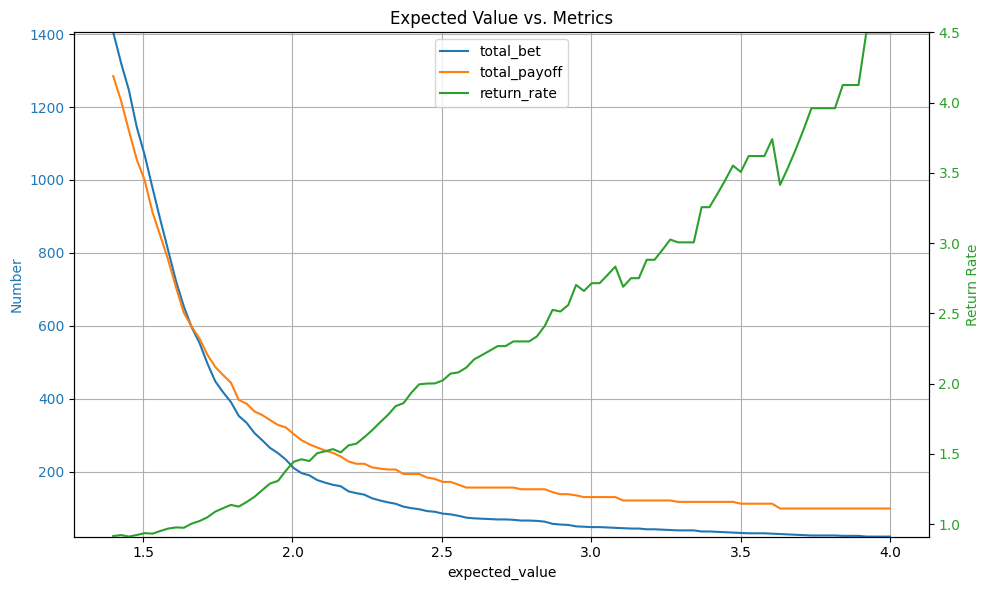

In [1]:
import improve_pred
improve_pred.num_horse_check()

## 実際に予想してみる

In [34]:
%autoreload

In [3]:
horse_results_preprocessed = preprocessing.process_horse_results(
    save_filename="horse_results_prediction.csv",
    input_filename="horse_results_prediction.csv",
    population_filename="prediction_population.csv"
)

In [3]:
hose_info_preprocessed = preprocessing.process_horse_info()

In [4]:
from feature_engeneering import PredictionFeatureCreator
pfc = PredictionFeatureCreator()

In [174]:
# 中京
features = pfc.create_features(race_id="202507010512")

100%|██████████| 5/5 [00:00<00:00, 38.36it/s]


shutuba
results


/home/mech-user/KEI.AI/v1_0_2/src/feature_engeneering.py:316: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[0]


race_info


In [5]:
# 中山
features = pfc.create_features(race_id="202406050811")

100%|██████████| 5/5 [00:00<00:00, 30.28it/s]


shutuba
results


/home/mech-user/KEI.AI/v1_0_2/src/feature_engeneering.py:316: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[0]


race_info


In [13]:
#`tansho_odds` 列を更新または新規作成
# features["tansho_odds"] = [13.2, 60.9, 24.8, 53.8, 8.5, 4.1, 5.4, 2.3, 34.5, 73.1, 11.5]
features["race_class"] = [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]

In [14]:
pfc.features[["umaban","rank_furlongs_1races_mean", "weight", "horse_id", "Front-Running", "race_class"]]

,umaban,rank_furlongs_1races_mean,weight,horse_id,Front-Running,race_class
0,1,0.0,520,2021105143,92,8
1,3,0.0,516,2021105436,1,8
2,4,0.0,432,2019105748,25,8
3,5,0.0,512,2020102781,69,8
4,6,0.0,506,2019105552,38,8
5,7,0.0,498,2019104740,15,8
6,8,0.0,468,2021105898,1,8
7,9,0.0,502,2017102170,110,8
8,10,0.0,474,2018104541,1,8
9,11,0.0,468,2019105346,49,8


In [15]:
from predict import predict
df = predict(features=features, config_filepath="config_new.yaml")
df

,race_id,umaban,tansho_odds,calibrated_pred,calibrated_expected_value
3,202406050811,5,7.1,0.240951,1.710755
6,202406050811,8,10.9,0.153584,1.674061
9,202406050811,11,10.9,0.153584,1.674061
5,202406050811,7,17.6,0.092715,1.631788
4,202406050811,6,17.2,0.092715,1.594702
8,202406050811,10,16.4,0.092715,1.520530
0,202406050811,1,4.0,0.342857,1.371429
1,202406050811,3,2.8,0.455696,1.275949
2,202406050811,4,35.1,0.034375,1.206563
11,202406050811,13,27.1,0.042254,1.145070
